<a href="https://colab.research.google.com/github/sarthakpankar/OIBSIP/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis on Twitter Data

Author: Sarthak Pankar  
Internship: Oasis Infobyte Data Analytics  
Task: Task 3 – Sentiment Analysis

This project analyzes Twitter text data and classifies sentiment as
positive, negative, or neutral using a Naive Bayes machine learning model.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
data = pd.read_csv("Twitter_Data.csv")
data.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [17]:
data.isnull().sum()

,0
clean_text,4
category,7


In [18]:
data = data.dropna()

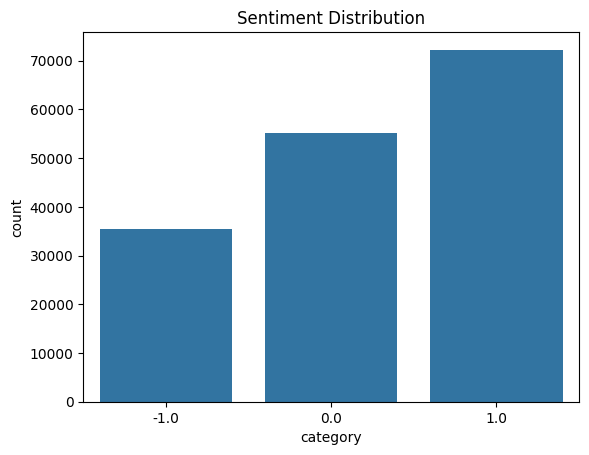

In [19]:
sns.countplot(x='category', data=data)
plt.title("Sentiment Distribution")
plt.show()

In [20]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    return text

data['clean_text'] = data['clean_text'].apply(clean_text)

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(data['clean_text'])

y = data['category']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [23]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [24]:
accuracy = model.score(X_test, y_test)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7501073817266982


## Model Testing


In [25]:
tweets = [
    "This phone is amazing",
    "This service is very bad",
    "The product is okay"
]

vector = vectorizer.transform(tweets)

predictions = model.predict(vector)

for tweet, pred in zip(tweets, predictions):
    print(tweet, "->", pred)

This phone is amazing -> 1.0
This service is very bad -> -1.0
The product is okay -> 1.0


In [26]:
test_tweet = ["This phone is amazing and very good"]

test_vector = vectorizer.transform(test_tweet)

prediction = model.predict(test_vector)

print("Prediction:", prediction)

Prediction: [1.]


Conclusion

This project performs sentiment analysis on Twitter data.
Tweets are classified as positive, negative, or neutral using the Naive Bayes algorithm.
The model achieved good accuracy in predicting sentiment.
